In [34]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Funzione gaussiana
def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Apri il file ROOT
file = uproot.open("/home/riccardo-speziali/after_waveforms_analysis/sampic_mcp_setup_run222_final.root")
tree = file["picoTree"]

# Converti in Awkward Array
data = tree.arrays(library="ak")

# Estrai branch rilevanti
Cell0TimeStamp_PICOSEC = data["Cell0timeSTamp_PICOSEC"]  # array di array
Cell0TimeStamp_MCP    = data["Cell0timestamp_MCP"]       # array piatto
cfd_PICO              = data["pulses_time_cfd30"]       # array di array
cfd_MCP               = data["mcp_time_cfd30"]          # array piatto
hits                  = data["hit_x_event"]             # numero di hit per evento
channel               = data["chanel_PICOSEC"]         # canale PICOSEC
srs                   = data["TriggerIDSRS_MCP"]      # Trigger ID SRS
amplitude_PICOSEC     = data["pulses_amplitude"]     # array di array
e_peak_PICOSEC        = data["pulses_integral"]        # array di array
track_chi_2          = data["track_chi_2"]             # chi2 del track






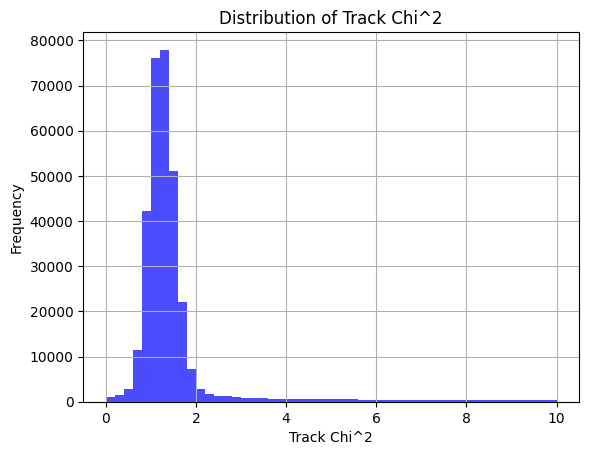

In [35]:
#fit track chi_2
chi_2_values = ak.to_numpy(track_chi_2)
chi_2_values = chi_2_values[~np.isnan(chi_2_values)]
plt.hist(chi_2_values, bins=50, range=(0, 10), alpha=0.7, color='blue')
plt.xlabel('Track Chi^2')
plt.ylabel('Frequency')
plt.title('Distribution of Track Chi^2')
plt.grid()
plt.show()

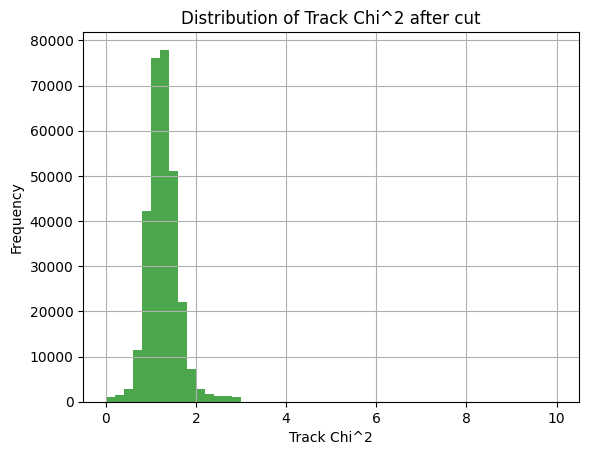

In [36]:
#keep events with good track fit anche per eventi con più di un hit
good_track_mask = chi_2_values < 3
good_tracks = ak.mask(track_chi_2, good_track_mask)
#plot track chi_2 distribution after cut
good_chi_2_values = ak.to_numpy(good_tracks)
good_chi_2_values = good_chi_2_values[~np.isnan(good_chi_2_values)]
plt.hist(good_chi_2_values, bins=50, range=(0, 10), alpha=0.7, color='green')
plt.xlabel('Track Chi^2')
plt.ylabel('Frequency')
plt.title('Distribution of Track Chi^2 after cut')
plt.grid()
plt.show()



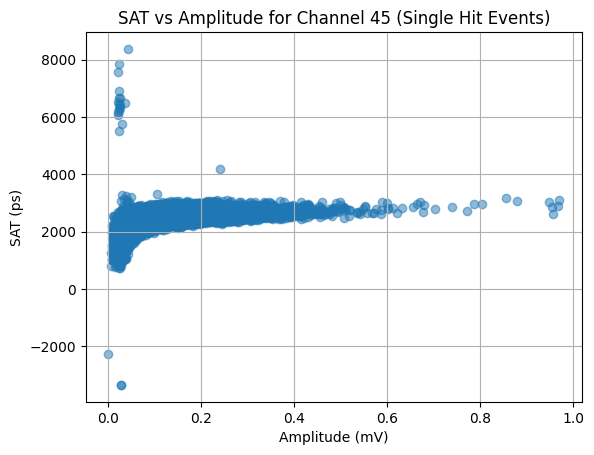

In [37]:
channel_mask = ak.any(channel == 45, axis=1)
single_hit_mask = hits == 1

valid_mask = (
    (ak.num(amplitude_PICOSEC) >= 1) &
    (ak.num(cfd_PICO) >= 1) &
    good_track_mask
)

event_mask = channel_mask & single_hit_mask & valid_mask

good_amplitude = amplitude_PICOSEC[event_mask][:,0]
good_SAT = cfd_PICO[event_mask][:,0]





plt.scatter(good_amplitude, good_SAT, alpha=0.5)
plt.xlabel('Amplitude (mV)')
plt.ylabel('SAT (ps)')
plt.title('SAT vs Amplitude for Channel 45 (Single Hit Events)')
plt.grid()
plt.show()

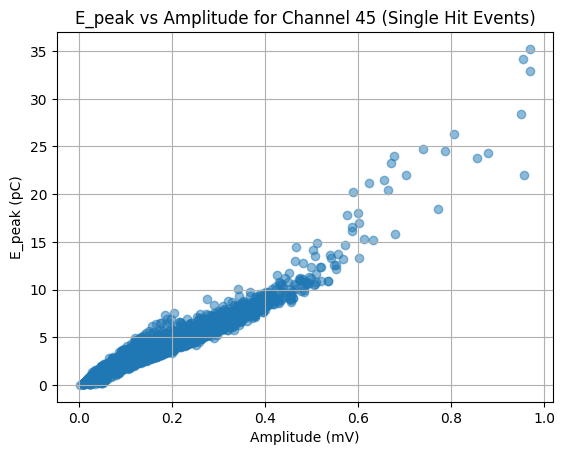

In [38]:
#amplitude vs e_peak
epeak_mask = ak.num(e_peak_PICOSEC) >= 1
valid_epeak_mask = event_mask & epeak_mask
good_epeak = e_peak_PICOSEC[valid_epeak_mask][:,0]

plt.scatter(good_amplitude, good_epeak, alpha=0.5)
plt.xlabel('Amplitude (mV)')
plt.ylabel('E_peak (pC)')
plt.title('E_peak vs Amplitude for Channel 45 (Single Hit Events)')
plt.grid()
plt.show()
